In [36]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [37]:
df = pd.read_csv(r"D:\sprints project\pca_data.csv")
df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Target
0,1.130664,-1.087655,3.164263,2.293052,0.023175,0.578814,0.664854,-0.536787,-1.495392,-0.499485,0
1,3.190926,-1.417885,-0.533715,-0.857970,-0.006289,0.745347,-0.259063,1.069777,0.342524,1.431509,1
2,3.124339,0.657008,-0.285134,-0.626641,0.152793,1.130179,-0.324995,0.209299,0.043205,0.462304,1
3,-0.484339,1.410972,0.397806,2.832741,0.721309,-0.388361,-0.522221,-2.153525,0.760079,0.228379,0
4,-2.284542,-0.330033,-0.072260,1.209318,0.770835,0.625587,0.379567,0.014736,1.050381,0.628110,0


### 1.Feature Importance (Random Forest)

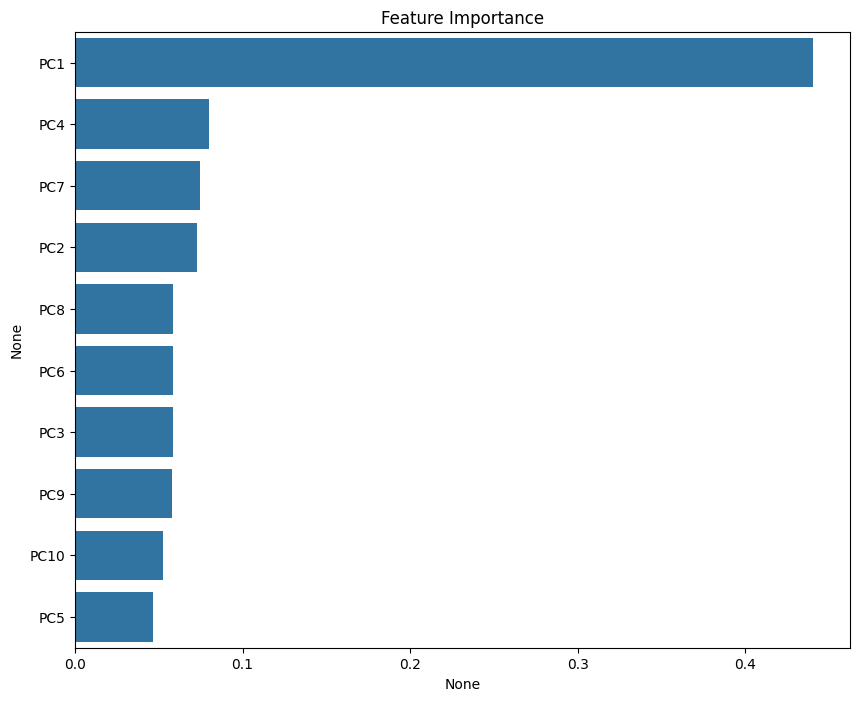

In [38]:
from sklearn.ensemble import RandomForestClassifier
X = df.drop(columns=['Target'])
y = df['Target']

rf = RandomForestClassifier(random_state=42)
rf.fit(X,y)

importances = pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=importances,y=importances.index)
plt.title('Feature Importance')
plt.show()

In [39]:
print(importances)

PC1     0.440602
PC4     0.079953
PC7     0.074358
PC2     0.072654
PC8     0.058755
PC6     0.058544
PC3     0.058356
PC9     0.057889
PC10    0.052242
PC5     0.046647
dtype: float64


### 2.Recursive Feature Elimination (RFE)

In [40]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000,solver='liblinear')
rfe = RFE(model,n_features_to_select=8)
rfe.fit(X,y)

selected_rfe = X.columns[rfe.support_]
print("Selected features by RFE:", list(selected_rfe))

Selected features by RFE: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC7', 'PC9', 'PC10']


### 3.Chi-Square Test

In [41]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

X_scaled = MinMaxScaler().fit_transform(X)

chi_scores, p_values = chi2(X_scaled, y)
chi_df = pd.DataFrame({
    'feature': X.columns,
    'chi2_score': chi_scores,
    'p_values': p_values
}).sort_values(by="chi2_score", ascending=False)
print("Chi-Square Test Results:\n", chi_df)

Chi-Square Test Results:
   feature  chi2_score  p_values
0     PC1   14.924561  0.000112
3     PC4    0.418761  0.517556
1     PC2    0.303308  0.581816
6     PC7    0.217743  0.640765
4     PC5    0.109811  0.740360
8     PC9    0.087658  0.767176
2     PC3    0.014081  0.905541
9    PC10    0.004669  0.945522
7     PC8    0.002929  0.956843
5     PC6    0.000027  0.995833


In [42]:
features_rf = set(importances.head(10).index)   # RandomForest
features_rfe = set(selected_rfe)                # RFE
features_chi2 = set(chi_df[chi_df["p_values"] < 0.05]["feature"])  # Chi-Square

final_features = features_rf | features_rfe | features_chi2

print("Final Selected Features for Modeling:")
print(final_features)

X_selected = df[list(final_features)]

Final Selected Features for Modeling:
{'PC4', 'PC5', 'PC2', 'PC1', 'PC8', 'PC3', 'PC9', 'PC7', 'PC6', 'PC10'}


In [43]:
df_selected = pd.concat([X_selected, y], axis=1)

In [44]:
df_selected.head()

,PC4,PC5,PC2,PC1,PC8,PC3,PC9,PC7,PC6,PC10,Target
0,2.293052,0.023175,-1.087655,1.130664,-0.536787,3.164263,-1.495392,0.664854,0.578814,-0.499485,0
1,-0.857970,-0.006289,-1.417885,3.190926,1.069777,-0.533715,0.342524,-0.259063,0.745347,1.431509,1
2,-0.626641,0.152793,0.657008,3.124339,0.209299,-0.285134,0.043205,-0.324995,1.130179,0.462304,1
3,2.832741,0.721309,1.410972,-0.484339,-2.153525,0.397806,0.760079,-0.522221,-0.388361,0.228379,0
4,1.209318,0.770835,-0.330033,-2.284542,0.014736,-0.072260,1.050381,0.379567,0.625587,0.628110,0


In [45]:
df_selected.to_csv("D:\sprints project\selected_data.csv", index=False)